In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow
import scipy
import seaborn as sns
import sklearn
from IPython.display import display

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
import gc
_ = gc.collect()

Для репрезентативного анализа используем фиксированное окно середины 2025 года: 91 календарный день, или ровно 13 недель. Такой срез не содержит предновогоднего пика и позволяет корректно оценивать недельную сезонность.

In [3]:
from datetime import date, timedelta

period_start = date(2025, 5, 17)
period_end = date(2025, 8, 15)

df = pd.read_parquet(
    "../data/train.parquet",
    engine="pyarrow",
    dtype_backend="pyarrow",
    filters=[
        ("event_date", ">=", period_start),
        ("event_date", "<=", period_end),
    ],
)

print(f'''
    Период: {df["event_date"].min()} — {df["event_date"].max()}
    Календарных дней: {(period_end - period_start).days + 1}
    Дат с наблюдениями: {df["event_date"].nunique()}
    Размер: {df.shape}
    Память: {df.memory_usage(deep=False).sum() / 1024**3:.2f} GiB
    ''')

assert (period_end - period_start).days + 1 == 91
assert df["event_date"].min() == period_start
assert df["event_date"].max() == period_end
assert df["event_date"].nunique() == 91


    Период: 2025-05-17 — 2025-08-15
    Календарных дней: 91
    Дат с наблюдениями: 91
    Размер: (6235139, 18)
    Память: 0.83 GiB
    


In [4]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
})

quality["missing_%"] = quality["missing"]/len(df) * 100

print(f'''
      Строк: {len(df)}
      Пользователей: {df["user_id"].nunique()}
''')
display(quality.sort_values("missing_%", ascending=False))


      Строк: 6235139
      Пользователей: 227663



,dtype,missing,missing_%
event_date,date32[day][pyarrow],0,0.0
user_id,int64[pyarrow],0,0.0
search,int64[pyarrow],0,0.0
cat,int64[pyarrow],0,0.0
has_search_to_cart,int64[pyarrow],0,0.0
has_search_to_ord,int64[pyarrow],0,0.0
has_cat_to_cart,int64[pyarrow],0,0.0
has_cat_to_ord,int64[pyarrow],0,0.0
search_to_cart,int64[pyarrow],0,0.0
search_to_ord,int64[pyarrow],0,0.0


In [5]:
binary_cols = [
    "search",
    "cat",
    "has_search_to_cart",
    "has_search_to_ord",
    "has_cat_to_cart",
    "has_cat_to_ord",
]

count_cols = [
    "search_to_cart",
    "search_to_ord",
    "cat_to_cart",
    "cat_to_ord",
    "to_cart",
    "to_ord",
    "searches",
]

gmv_cols = ["gmv_search", "gmv_cat", "gmv"]

duplicate_user_days = df.duplicated(["user_id", "event_date"]).sum()

invalid_binary = {
    col: (~df[col].isin([0, 1])).sum()
    for col in binary_cols
}

negative_values = {
    col: (df[col] < 0).sum()
    for col in count_cols + gmv_cols
}

print(f'''
Дубликаты user_id × event_date: {duplicate_user_days}
Некорректные бинарные значения: {invalid_binary}
Отрицательные значения: {negative_values}
''')


Дубликаты user_id × event_date: 0
Некорректные бинарные значения: {'search': np.int64(0), 'cat': np.int64(0), 'has_search_to_cart': np.int64(0), 'has_search_to_ord': np.int64(0), 'has_cat_to_cart': np.int64(0), 'has_cat_to_ord': np.int64(0)}
Отрицательные значения: {'search_to_cart': 0, 'search_to_ord': 0, 'cat_to_cart': 0, 'cat_to_ord': 0, 'to_cart': 0, 'to_ord': 0, 'searches': 0, 'gmv_search': 0, 'gmv_cat': 0, 'gmv': 0}



In [6]:
consistency_checks = []

checks = [
    ("GMV", "gmv", "gmv_search", "gmv_cat", 1e-8),
    ("Купленные товары", "to_ord", "search_to_ord", "cat_to_ord", 0),
    ("Добавления в корзину", "to_cart", "search_to_cart", "cat_to_cart", 0),
]

for name, total_col, search_col, cat_col, tolerance in checks:
    residual = (
        df[total_col]
        - df[search_col]
        - df[cat_col]
    )

    consistency_checks.append({
        "Показатель": name,
        "Отрицательный остаток": int((residual < -tolerance).sum()),
        "Положительный остаток": int((residual > tolerance).sum()),
        "Сумма остатка": float(residual.sum()),
    })

    del residual

consistency_checks = pd.DataFrame(consistency_checks)
display(consistency_checks)

,Показатель,Отрицательный остаток,Положительный остаток,Сумма остатка
0,GMV,0,0,-2.780149e-11
1,Купленные товары,0,0,0.000000e+00
2,Добавления в корзину,0,0,0.000000e+00


Агрегируем GMV за 91 день по каждому пользователю и считаем долю пользователей без покупок

In [7]:
user_gmv = (
    df.groupby("user_id", as_index=False)["gmv"]
    .sum()
    .rename(columns={"gmv": "gmv_91d"})
)

gmv_values = user_gmv["gmv_91d"].to_numpy(dtype="float64")

zero_users = (gmv_values == 0).sum()
zero_share = zero_users / len(gmv_values)

quantiles = user_gmv["gmv_91d"].quantile(
    [0.5, 0.95, 0.99, 0.999]
    )

print(f'''
Пользователей: {len(user_gmv):,}
Пользователей с нулевым GMV: {zero_users:,}
Доля нулевого GMV: {zero_share:.2%}
''')

display(quantiles.rename(index={
        0.50: "50%",
        0.95: "95%",
        0.99: "99%",
        0.999: "99.9%",
    })
    .to_frame("GMV за 91 день")
)


Пользователей: 227,663
Пользователей с нулевым GMV: 67,923
Доля нулевого GMV: 29.83%



,GMV за 91 день
50%,60.838044
95%,1109.800319
99%,2659.302537
99.9%,7118.721323


Получили заметную нулевую инфляцию: за 91 день GMV отсутствует у 29.83% пользователей текущего окна.

In [8]:
positive_gmv = gmv_values[gmv_values > 0]

gmv_skewness = scipy.stats.skew(
    gmv_values,
    bias=False
)

gmv_kurtosis = scipy.stats.kurtosis(
    gmv_values,
    bias=False,
    fisher=True,
)

sorted_gmv = np.sort(gmv_values)[::-1]
total_gmv = sorted_gmv.sum()

whale_rows = []
for top_share in [0.05, 0.01, 0.001]:
    top_users = int(np.ceil(len(sorted_gmv) * top_share))
    whale_gmv = sorted_gmv[:top_users].sum()
    whale_rows.append({
        "Доля пользователей": f"{top_share:.1%}",
        "Пользователей": top_users,
        "GMV": whale_gmv,
        "Доля GMV": whale_gmv / total_gmv,
    })
    
whale_summary = pd.DataFrame(whale_rows)

print(f'''
Skewness GMV: {gmv_skewness:.2f}
Excess kurtosis GMV: {gmv_kurtosis:.2f}
Пользователей с положительным GMV: {len(positive_gmv):,}
Общий GMV за 91 день: {total_gmv:,.2f}
''')

display(whale_summary)


Skewness GMV: 13.00
Excess kurtosis GMV: 422.62
Пользователей с положительным GMV: 159,740
Общий GMV за 91 день: 58,523,035.46



,Доля пользователей,Пользователей,GMV,Доля GMV
0,5.0%,11384,2.512638e+07,0.429342
1,1.0%,2277,1.036966e+07,0.177189
2,0.1%,228,2.530375e+06,0.043237


Распределение крайне асимметрично: top-5% формируют 42.93% GMV, а excess kurtosis 422.62 указывает на тяжёлый правый хвост.

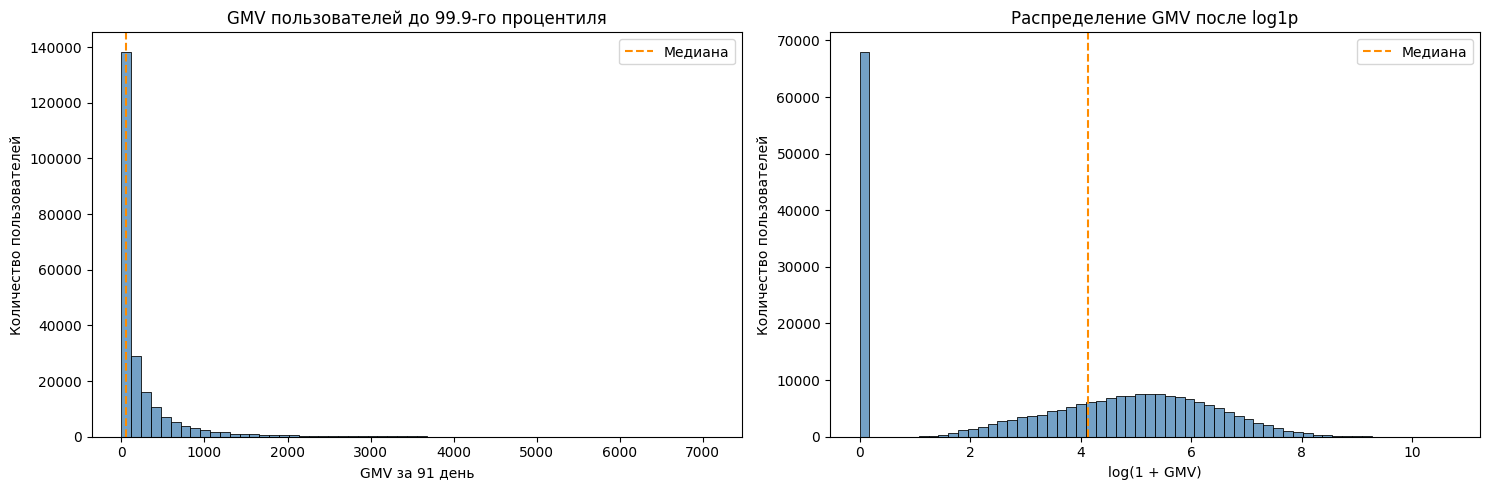

In [9]:
gmv_999 = np.quantile(gmv_values, 0.999)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(
    gmv_values[gmv_values <= gmv_999],
    bins=60,
    ax=axes[0],
    color="steelblue",
)

axes[0].axvline(
    np.median(gmv_values),
    color="darkorange",
    linestyle="--",
    label="Медиана",
)

axes[0].set_title("GMV пользователей до 99.9-го процентиля")
axes[0].set_xlabel("GMV за 91 день")
axes[0].set_ylabel("Количество пользователей")
axes[0].legend()

sns.histplot(
    np.log1p(gmv_values),
    bins=60,
    ax=axes[1],
    color="steelblue",
)

axes[1].axvline(
    np.log1p(np.median(gmv_values)),
    color="darkorange",
    linestyle="--",
    label="Медиана",
)

axes[1].set_title("Распределение GMV после log1p")
axes[1].set_xlabel("log(1 + GMV)")
axes[1].set_ylabel("Количество пользователей")
axes[1].legend()

plt.tight_layout()
plt.show()

- отдельный пик нулевого GMV — 29.83% пользователей;
- положительный GMV после log1p становится значительно ближе к колоколообразному распределению, хотя асимметрия сохраняется.

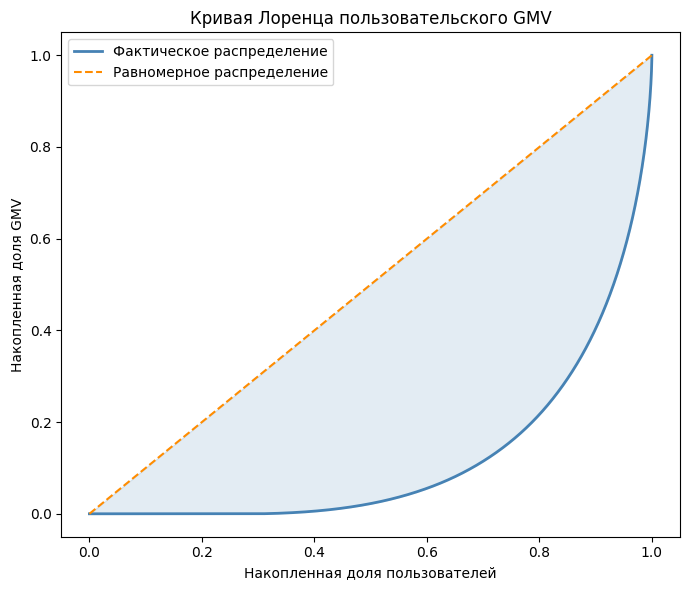

In [10]:
sorted_gmv_asc = np.sort(gmv_values)

cumulative_gmv_share = np.cumsum(sorted_gmv_asc) / sorted_gmv_asc.sum()
cumulative_users_share = np.arange(1, len(sorted_gmv_asc)+1) / len(sorted_gmv_asc)

cumulative_gmv_share = np.insert(cumulative_gmv_share, 0, 0)
cumulative_users_share = np.insert(cumulative_users_share, 0, 0)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    cumulative_users_share,
    cumulative_gmv_share,
    color="steelblue",
    linewidth=2,
    label="Фактическое распределение",
)

ax.plot(
    [0, 1],
    [0, 1],
    color="darkorange",
    linestyle="--",
    label="Равномерное распределение",
)

ax.fill_between(
    cumulative_users_share,
    cumulative_gmv_share,
    cumulative_users_share,
    color="steelblue",
    alpha=0.15,
)

ax.set_title("Кривая Лоренца пользовательского GMV")
ax.set_xlabel("Накопленная доля пользователей")
ax.set_ylabel("Накопленная доля GMV")
ax.legend()

plt.tight_layout()
plt.show()

In [11]:
sorted_gmv_ascending = np.sort(
    gmv_values.astype("float64")
)

n_users = len(sorted_gmv_ascending)

cumulative_gmv = np.cumsum(
    sorted_gmv_ascending,
    dtype="float64",
)

total_gmv_check = cumulative_gmv[-1]

population_share = np.arange(
    n_users + 1,
    dtype="float64",
) / n_users

lorenz_share = np.concatenate([
    [0.0],
    cumulative_gmv / total_gmv_check,
])

# Метод 1: площадь между кривой Лоренца и диагональю.
gini_lorenz = 1 - 2 * np.trapezoid(
    lorenz_share,
    population_share,
)

# Метод 2: ранговая формула.
ranks = np.arange(
    1,
    n_users + 1,
    dtype="float64",
)

gini_ranks = (
    2 * np.dot(ranks, sorted_gmv_ascending)
    / (n_users * total_gmv_check)
    - (n_users + 1) / n_users
)

top_5_count = int(np.ceil(n_users * 0.05))

top_5_share_check = (
    sorted_gmv_ascending[-top_5_count:].sum()
    / total_gmv_check
)

bottom_95_share_check = (
    sorted_gmv_ascending[:-top_5_count].sum()
    / total_gmv_check
)

print(f"""
Gini по кривой Лоренца: {gini_lorenz:.6f}
Gini по ранговой формуле: {gini_ranks:.6f}

Доля GMV bottom-95%: {bottom_95_share_check:.2%}
Доля GMV top-5%: {top_5_share_check:.2%}
Сумма долей: {bottom_95_share_check + top_5_share_check:.2%}
""")

assert np.isclose(gini_lorenz, gini_ranks)
assert np.isclose(
    bottom_95_share_check + top_5_share_check,
    1.0,
)


Gini по кривой Лоренца: 0.760771
Gini по ранговой формуле: 0.760771

Доля GMV bottom-95%: 57.07%
Доля GMV top-5%: 42.93%
Сумма долей: 100.00%



Коэффициент Джини — 0.761, что согласуется с тяжёлым хвостом и высокой концентрацией GMV.

In [12]:
user_rfm = (
    df.groupby("user_id", as_index=False)
    .agg(
        first_activity=("event_date", "min"),
        last_activity=("event_date", "max"),
        active_days=("event_date", "nunique"),
        searches_91d=("searches", "sum"),
        purchased_items_91d=("to_ord", "sum"),
        gmv_91d=("gmv", "sum"),
        gmv_search_91d=("gmv_search", "sum"),
        gmv_cat_91d=("gmv_cat", "sum"),
    )
)

print(f"""
Строк в пользовательской таблице: {len(user_rfm):,}
Уникальных пользователей: {user_rfm["user_id"].nunique():,}
Среднее число активных дней: {user_rfm["active_days"].mean():.2f}
Медианное число активных дней: {user_rfm["active_days"].median():.0f}
Суммарное число поисковых запросов: {user_rfm["searches_91d"].sum():,.0f}
Суммарное число купленных товаров: {user_rfm["purchased_items_91d"].sum():,.0f}
Суммарный GMV: {user_rfm["gmv_91d"].sum():,.2f}
""")

assert len(user_rfm) == df["user_id"].nunique()
assert user_rfm["user_id"].is_unique
assert np.isclose(
    user_rfm["gmv_91d"].sum(),
    df["gmv"].sum(),
)

display(user_rfm.head())


Строк в пользовательской таблице: 227,663
Уникальных пользователей: 227,663
Среднее число активных дней: 27.39
Медианное число активных дней: 23
Суммарное число поисковых запросов: 19,717,732
Суммарное число купленных товаров: 1,692,631
Суммарный GMV: 58,523,035.46



,user_id,first_activity,last_activity,active_days,searches_91d,purchased_items_91d,gmv_91d,gmv_search_91d,gmv_cat_91d
0,2,2025-06-16,2025-08-08,3,4,0,0.0,0.0,0.0
1,7,2025-05-21,2025-08-14,20,53,9,103.536842,103.536842,0.0
2,15,2025-05-24,2025-08-15,11,13,0,0.0,0.0,0.0
3,18,2025-05-19,2025-08-12,29,60,9,425.103482,425.103482,0.0
4,23,2025-06-29,2025-06-29,1,1,0,0.0,0.0,0.0


Пользовательские агрегаты за 91 день

Переходим от дневных наблюдений к одной строке на пользователя.

- `user_id` — идентификатор пользователя;
- `first_activity` — первая дата присутствия в рассматриваемом окне;
- `last_activity` — последняя дата присутствия в рассматриваемом окне;
- `active_days` — число уникальных дней присутствия;
- `searches_91d` — суммарное число поисковых запросов;
- `purchased_items_91d` — суммарное число купленных товаров, не заказов;
- `gmv_91d` — общий GMV;
- `gmv_search_91d` — GMV поискового канала;
- `gmv_cat_91d` — GMV каталожного канала.

In [13]:
purchase_days = (
    df.loc[df["to_ord"] > 0]
    .groupby("user_id")
    .size()
    .rename("purchase_days")
)

search_days = (
    df.loc[df["search"] == 1]
    .groupby("user_id")
    .size()
    .rename("search_days")
)

catalog_days = (
    df.loc[df["cat"] == 1]
    .groupby("user_id")
    .size()
    .rename("catalog_days")
)

event_days = (
    pd.concat(
        [
            purchase_days,
            search_days,
            catalog_days,
        ],
        axis=1,
    )
    .reset_index()
)

event_day_columns = [
    "purchase_days",
    "search_days",
    "catalog_days",
]

user_rfm = (
    user_rfm
    .drop(
        columns=event_day_columns,
        errors="ignore",
    )
    .merge(
        event_days,
        on="user_id",
        how="left",
        validate="one_to_one",
    )
)

# Пользователи, не попавшие ни в одну из отфильтрованных групп,
# появляются после merge с NaN. Для количества событий это означает 0.
user_rfm[event_day_columns] = (
    user_rfm[event_day_columns]
    .fillna(0)
    .astype("int32")
)

users_without_purchases = (
    user_rfm["purchase_days"] == 0
).sum()

users_without_search = (
    user_rfm["search_days"] == 0
).sum()

users_without_catalog = (
    user_rfm["catalog_days"] == 0
).sum()

print(f"""
Пользователей без покупок: {users_without_purchases:,}
Медиана покупочных дней: {user_rfm["purchase_days"].median():.0f}

Пользователей без поиска: {users_without_search:,}
Медиана поисковых дней: {user_rfm["search_days"].median():.0f}

Пользователей без каталога: {users_without_catalog:,}
Медиана каталожных дней: {user_rfm["catalog_days"].median():.0f}
""")

assert user_rfm["user_id"].is_unique
assert len(user_rfm) == df["user_id"].nunique()
assert user_rfm[event_day_columns].isna().sum().sum() == 0

assert (
    (user_rfm["purchase_days"] > 0)
    == (user_rfm["purchased_items_91d"] > 0)
).all()

display(
    user_rfm[
        [
            "user_id",
            "active_days",
            "purchase_days",
            "search_days",
            "catalog_days",
        ]
    ].head()
)


Пользователей без покупок: 67,923
Медиана покупочных дней: 2

Пользователей без поиска: 3,354
Медиана поисковых дней: 17

Пользователей без каталога: 67,795
Медиана каталожных дней: 2



,user_id,active_days,purchase_days,search_days,catalog_days
0,2,3,0,3,0
1,7,20,8,20,0
2,15,11,0,9,0
3,18,29,5,26,2
4,23,1,0,1,0


In [14]:
last_event_dates = pd.concat(
    [
        df.loc[df["to_ord"] > 0]
        .groupby("user_id")["event_date"]
        .max()
        .rename("last_purchase"),

        df.loc[df["search"] == 1]
        .groupby("user_id")["event_date"]
        .max()
        .rename("last_search"),

        df.loc[df["cat"] == 1]
        .groupby("user_id")["event_date"]
        .max()
        .rename("last_catalog"),
    ],
    axis=1,
).reset_index()

user_rfm = (
    user_rfm
    .drop(
        columns=[
            "last_purchase",
            "last_search",
            "last_catalog",
            "recency_any",
            "recency_purchase",
            "recency_search",
            "recency_catalog",
            "customer_age_91d",
        ],
        errors="ignore",
    )
    .merge(
        last_event_dates,
        on="user_id",
        how="left",
        validate="one_to_one",
    )
)

date_columns = [
    "first_activity",
    "last_activity",
    "last_purchase",
    "last_search",
    "last_catalog",
]

for column in date_columns:
    user_rfm[column] = pd.to_datetime(user_rfm[column])

period_end_timestamp = pd.Timestamp(period_end)

user_rfm["recency_any"] = (
    period_end_timestamp - user_rfm["last_activity"]
).dt.days

user_rfm["recency_purchase"] = (
    period_end_timestamp - user_rfm["last_purchase"]
).dt.days

user_rfm["recency_search"] = (
    period_end_timestamp - user_rfm["last_search"]
).dt.days

user_rfm["recency_catalog"] = (
    period_end_timestamp - user_rfm["last_catalog"]
).dt.days

user_rfm["customer_age_91d"] = (
    period_end_timestamp - user_rfm["first_activity"]
).dt.days + 1

print(f'''
Медианная давность любой активности: {user_rfm["recency_any"].median():.0f} дней
Медианная давность покупки: {user_rfm["recency_purchase"].median():.0f} дней
Медианная давность поиска: {user_rfm["recency_search"].median():.0f} дней
Медианная давность каталога: {user_rfm["recency_catalog"].median():.0f} дней

Нет даты покупки: {user_rfm["last_purchase"].isna().sum():,}
Нет даты поиска: {user_rfm["last_search"].isna().sum():,}
Нет даты каталога: {user_rfm["last_catalog"].isna().sum():,}
''')


Медианная давность любой активности: 2 дней
Медианная давность покупки: 12 дней
Медианная давность поиска: 3 дней
Медианная давность каталога: 16 дней

Нет даты покупки: 67,923
Нет даты поиска: 3,354
Нет даты каталога: 67,795



Видна высокая общая вовлечённость: медианный пользователь был активен за 2 дня до конца периода, использовал поиск 3 дня назад, а покупал 12 дней назад. Каталог используется заметно реже поиска.

In [15]:
def safe_divide(numerator, denominator):
    numerator = np.asarray(numerator, dtype="float64")
    denominator = np.asarray(denominator, dtype="float64")

    result = np.full(
        numerator.shape,
        np.nan,
        dtype="float64",
    )

    np.divide(
        numerator,
        denominator,
        out=result,
        where=denominator != 0,
    )

    return result


observation_days = df["event_date"].nunique()

gmv_square_sum = (
    (df["gmv"] ** 2)
    .groupby(df["user_id"])
    .sum()
    .rename("gmv_square_sum")
    .reset_index()
)

user_rfm = (
    user_rfm
    .drop(
        columns=[
            "gmv_square_sum",
            "gmv_per_purchased_item",
            "gmv_daily_mean",
            "gmv_daily_std",
            "gmv_daily_cv",
        ],
        errors="ignore",
    )
    .merge(
        gmv_square_sum,
        on="user_id",
        how="left",
        validate="one_to_one",
    )
)

user_rfm["gmv_per_purchased_item"] = safe_divide(
    user_rfm["gmv_91d"],
    user_rfm["purchased_items_91d"],
)

user_rfm["gmv_daily_mean"] = (
    user_rfm["gmv_91d"] / observation_days
)

gmv_daily_variance = (
    user_rfm["gmv_square_sum"] / observation_days
    - user_rfm["gmv_daily_mean"] ** 2
).clip(lower=0)

user_rfm["gmv_daily_std"] = np.sqrt(
    gmv_daily_variance
)

user_rfm["gmv_daily_cv"] = safe_divide(
    user_rfm["gmv_daily_std"],
    user_rfm["gmv_daily_mean"],
)

print(f"""
Дней в окне: {observation_days}

Медианный GMV на купленный товар: {user_rfm["gmv_per_purchased_item"].median():.2f}
Медианный среднедневной GMV: {user_rfm["gmv_daily_mean"].median():.2f}
Медианное стандартное отклонение дневного GMV: {user_rfm["gmv_daily_std"].median():.2f}
Медианный CV дневного GMV: {user_rfm["gmv_daily_cv"].median():.2f}

CV не определён для пользователей с нулевым GMV:
{user_rfm["gmv_daily_cv"].isna().sum():,}
""")

assert (
    user_rfm["gmv_daily_cv"].isna().sum()
    == (user_rfm["gmv_91d"] == 0).sum()
)


Дней в окне: 91

Медианный GMV на купленный товар: 23.87
Медианный среднедневной GMV: 0.67
Медианное стандартное отклонение дневного GMV: 4.38
Медианный CV дневного GMV: 5.90

CV не определён для пользователей с нулевым GMV:
67,923



CV 5.90 означает, что покупки происходят неравномерно: редкие дни с GMV сильно превышают обычный среднедневной уровень.

In [16]:
user_funnel = (
    df.groupby("user_id", as_index=False)
    .agg(
        search_to_cart_items_91d=("search_to_cart", "sum"),
        search_purchased_items_91d=("search_to_ord", "sum"),
        catalog_to_cart_items_91d=("cat_to_cart", "sum"),
        catalog_purchased_items_91d=("cat_to_ord", "sum"),
        cart_items_91d=("to_cart", "sum"),
        search_purchase_days=("has_search_to_ord", "sum"),
        catalog_purchase_days=("has_cat_to_ord", "sum"),
    )
)

cart_days = (
    (df["to_cart"] > 0)
    .groupby(df["user_id"])
    .sum()
    .rename("cart_days")
)

cart_without_purchase_days = (
    (
        (df["to_cart"] > 0)
        & (df["to_ord"] == 0)
    )
    .groupby(df["user_id"])
    .sum()
    .rename("cart_without_purchase_days")
)

cart_day_metrics = (
    pd.concat(
        [
            cart_days,
            cart_without_purchase_days,
        ],
        axis=1,
    )
    .reset_index()
)

user_funnel = user_funnel.merge(
    cart_day_metrics,
    on="user_id",
    how="left",
    validate="one_to_one",
)

funnel_columns = [
    column
    for column in user_funnel.columns
    if column != "user_id"
]

user_funnel[funnel_columns] = (
    user_funnel[funnel_columns]
    .fillna(0)
)

user_rfm = (
    user_rfm
    .drop(
        columns=funnel_columns,
        errors="ignore",
    )
    .merge(
        user_funnel,
        on="user_id",
        how="left",
        validate="one_to_one",
    )
)

print(f"""
Добавлено показателей микроворонки: {len(funnel_columns)}
Пользователей с добавлениями в корзину: {(user_rfm["cart_days"] > 0).sum():,}
Пользователей с покупками через поиск: {(user_rfm["search_purchased_items_91d"] > 0).sum():,}
Пользователей с покупками через каталог: {(user_rfm["catalog_purchased_items_91d"] > 0).sum():,}
""")

assert user_rfm["user_id"].is_unique
assert user_rfm[funnel_columns].isna().sum().sum() == 0


Добавлено показателей микроворонки: 9
Пользователей с добавлениями в корзину: 203,014
Пользователей с покупками через поиск: 157,102
Пользователей с покупками через каталог: 38,654



Покупки через поиск охватывают значительно больше пользователей, чем каталог.

In [17]:
user_rfm["sci_items_per_query"] = safe_divide(
    user_rfm["search_purchased_items_91d"],
    user_rfm["searches_91d"],
)

user_rfm["search_day_conversion"] = safe_divide(
    user_rfm["search_purchase_days"],
    user_rfm["search_days"],
)

user_rfm["catalog_day_conversion"] = safe_divide(
    user_rfm["catalog_purchase_days"],
    user_rfm["catalog_days"],
)

user_rfm["cart_to_purchase_rate"] = safe_divide(
    user_rfm["purchased_items_91d"],
    user_rfm["cart_items_91d"],
)

user_rfm["item_cart_gap"] = (
    1 - user_rfm["cart_to_purchase_rate"]
)

user_rfm["cart_without_purchase_day_share"] = safe_divide(
    user_rfm["cart_without_purchase_days"],
    user_rfm["cart_days"],
)

user_rfm["search_purchased_item_share"] = safe_divide(
    user_rfm["search_purchased_items_91d"],
    user_rfm["purchased_items_91d"],
)

user_rfm["search_gmv_share"] = safe_divide(
    user_rfm["gmv_search_91d"],
    user_rfm["gmv_91d"],
)

user_rfm["unattributed_gmv_91d"] = (
    user_rfm["gmv_91d"]
    - user_rfm["gmv_search_91d"]
    - user_rfm["gmv_cat_91d"]
)

overall_sci = (
    user_rfm["search_purchased_items_91d"].sum()
    / user_rfm["searches_91d"].sum()
)

overall_search_day_conversion = (
    user_rfm["search_purchase_days"].sum()
    / user_rfm["search_days"].sum()
)

overall_catalog_day_conversion = (
    user_rfm["catalog_purchase_days"].sum()
    / user_rfm["catalog_days"].sum()
)

overall_cart_to_purchase_rate = (
    user_rfm["purchased_items_91d"].sum()
    / user_rfm["cart_items_91d"].sum()
)

overall_cart_without_purchase_share = (
    user_rfm["cart_without_purchase_days"].sum()
    / user_rfm["cart_days"].sum()
)

overall_search_item_share = (
    user_rfm["search_purchased_items_91d"].sum()
    / user_rfm["purchased_items_91d"].sum()
)

overall_search_gmv_share = (
    user_rfm["gmv_search_91d"].sum()
    / user_rfm["gmv_91d"].sum()
)

users_with_rate_above_one = (
    user_rfm["cart_to_purchase_rate"] > 1
).sum()

print(f"""
SCI — купленных через поиск товаров на запрос: {overall_sci:.2%}

Конверсия поискового дня в покупку: {overall_search_day_conversion:.2%}
Конверсия каталожного дня в покупку: {overall_catalog_day_conversion:.2%}

Конверсия добавленных товаров в купленные: {overall_cart_to_purchase_rate:.2%}
Доля дней с корзиной, но без покупки: {overall_cart_without_purchase_share:.2%}

Доля купленных товаров через поиск: {overall_search_item_share:.2%}
Доля GMV через поиск: {overall_search_gmv_share:.2%}

Суммарный неатрибутированный GMV:
{user_rfm["unattributed_gmv_91d"].sum():.10f}

Пользователей с cart-to-purchase rate выше 100%:
{users_with_rate_above_one:,}
""")


SCI — купленных через поиск товаров на запрос: 8.12%

Конверсия поискового дня в покупку: 18.77%
Конверсия каталожного дня в покупку: 7.32%

Конверсия добавленных товаров в купленные: 26.68%
Доля дней с корзиной, но без покупки: 57.34%

Доля купленных товаров через поиск: 94.55%
Доля GMV через поиск: 92.69%

Суммарный неатрибутированный GMV:
-0.0000000000

Пользователей с cart-to-purchase rate выше 100%:
0



- SCI показывает купленные товары на один запрос, а не вероятность конверсии сессии.
- Доля дней с корзиной без покупки - прокси метрика: связать конкретную корзину с конкретной покупкой данные не позволяют.
- Значение выше 100% возможно, если покупка произошла из корзины, сформированной раньше рассматриваемого окна или дня.

Поиск — основной коммерческий канал: через него проходят 94.55% купленных товаров и 92.69% GMV. Конверсия поискового дня примерно в 2.6 раза выше каталожного. Неатрибутированного GMV фактически нет.

In [18]:
last_7_start = period_end - timedelta(days=6)

first_45_start = period_start
first_45_end = period_start + timedelta(days=44)

middle_date = first_45_end + timedelta(days=1)

last_45_start = period_end - timedelta(days=44)
last_45_end = period_end


def aggregate_activity_window(start_date, end_date, suffix):
    window_mask = (
        (df["event_date"] >= start_date)
        & (df["event_date"] <= end_date)
    )

    return (
        df.loc[window_mask]
        .groupby("user_id", as_index=False)
        .agg(
            **{
                f"searches_{suffix}": ("searches", "sum"),
                f"cart_items_{suffix}": ("to_cart", "sum"),
                f"purchased_items_{suffix}": ("to_ord", "sum"),
            }
        )
    )


activity_last_7d = aggregate_activity_window(
    last_7_start,
    period_end,
    "last_7d",
)

activity_first_45d = aggregate_activity_window(
    first_45_start,
    first_45_end,
    "first_45d",
)

activity_last_45d = aggregate_activity_window(
    last_45_start,
    last_45_end,
    "last_45d",
)

velocity_columns = [
    column
    for table in [
        activity_last_7d,
        activity_first_45d,
        activity_last_45d,
    ]
    for column in table.columns
    if column != "user_id"
]

user_rfm = user_rfm.drop(
    columns=velocity_columns,
    errors="ignore",
)

for activity_table in [
    activity_last_7d,
    activity_first_45d,
    activity_last_45d,
]:
    user_rfm = user_rfm.merge(
        activity_table,
        on="user_id",
        how="left",
        validate="one_to_one",
    )

user_rfm[velocity_columns] = (
    user_rfm[velocity_columns]
    .fillna(0)
)

print(f"""
Последние 7 дней: {last_7_start} — {period_end}

Первые 45 дней: {first_45_start} — {first_45_end}
Исключённый центральный день: {middle_date}
Последние 45 дней: {last_45_start} — {last_45_end}

Пользователей с поисками за последние 7 дней:
{(user_rfm["searches_last_7d"] > 0).sum():,}

Пользователей с покупками за последние 7 дней:
{(user_rfm["purchased_items_last_7d"] > 0).sum():,}
""")

assert user_rfm[velocity_columns].isna().sum().sum() == 0
assert (
    user_rfm["searches_last_7d"]
    <= user_rfm["searches_91d"]
).all()


Последние 7 дней: 2025-08-09 — 2025-08-15

Первые 45 дней: 2025-05-17 — 2025-06-30
Исключённый центральный день: 2025-07-01
Последние 45 дней: 2025-07-02 — 2025-08-15

Пользователей с поисками за последние 7 дней:
152,452

Пользователей с покупками за последние 7 дней:
57,258



Охват за последнюю неделю диапазона высокий: поиском пользовались 152 452 человека, покупки совершили 57 258.

In [19]:
user_rfm["search_velocity_7d_vs_91d"] = safe_divide(
    user_rfm["searches_last_7d"] / 7,
    user_rfm["searches_91d"] / 91,
)

user_rfm["cart_velocity_7d_vs_91d"] = safe_divide(
    user_rfm["cart_items_last_7d"] / 7,
    user_rfm["cart_items_91d"] / 91,
)

user_rfm["purchase_velocity_7d_vs_91d"] = safe_divide(
    user_rfm["purchased_items_last_7d"] / 7,
    user_rfm["purchased_items_91d"] / 91,
)

overall_search_velocity = (
    user_rfm["searches_last_7d"].sum() / 7
) / (
    user_rfm["searches_91d"].sum() / 91
)

overall_cart_velocity = (
    user_rfm["cart_items_last_7d"].sum() / 7
) / (
    user_rfm["cart_items_91d"].sum() / 91
)

overall_purchase_velocity = (
    user_rfm["purchased_items_last_7d"].sum() / 7
) / (
    user_rfm["purchased_items_91d"].sum() / 91
)

print(f"""
Совокупная скорость поиска: {overall_search_velocity:.2f}
Медианная пользовательская скорость поиска:
{user_rfm["search_velocity_7d_vs_91d"].median():.2f}

Совокупная скорость добавлений в корзину: {overall_cart_velocity:.2f}
Медианная пользовательская скорость добавлений:
{user_rfm["cart_velocity_7d_vs_91d"].median():.2f}

Совокупная скорость покупок: {overall_purchase_velocity:.2f}
Медианная пользовательская скорость покупок:
{user_rfm["purchase_velocity_7d_vs_91d"].median():.2f}

Пользователей без поисков за все 91 день:
{user_rfm["search_velocity_7d_vs_91d"].isna().sum():,}

Пользователей без добавлений за все 91 день:
{user_rfm["cart_velocity_7d_vs_91d"].isna().sum():,}

Пользователей без покупок за все 91 день:
{user_rfm["purchase_velocity_7d_vs_91d"].isna().sum():,}
""")


Совокупная скорость поиска: 1.10
Медианная пользовательская скорость поиска:
0.65

Совокупная скорость добавлений в корзину: 1.12
Медианная пользовательская скорость добавлений:
0.00

Совокупная скорость покупок: 1.15
Медианная пользовательская скорость покупок:
0.00

Пользователей без поисков за все 91 день:
3,354

Пользователей без добавлений за все 91 день:
24,649

Пользователей без покупок за все 91 день:
67,923



Интерпретация коэффициента:
- 1.0 - активность последней недели совпадает со среднедневной;
- больше 1.0 - активность ускорилась;
- меньше 1.0 - активность снизилась;

В последнюю неделю совокупная интенсивность выросла относительно среднего уровня окна: поиск — в 1.10 раза, корзина — в 1.12 раза, покупки — в 1.15 раза. При этом медианные пользовательские коэффициенты остаются ниже единицы: рост общего объёма поддерживает более активная часть аудитории, а покупки типичного пользователя остаются редкими.

In [20]:
user_rfm["search_trend_ratio_45d"] = safe_divide(
    user_rfm["searches_last_45d"],
    user_rfm["searches_first_45d"],
)

user_rfm["cart_trend_ratio_45d"] = safe_divide(
    user_rfm["cart_items_last_45d"],
    user_rfm["cart_items_first_45d"],
)

user_rfm["purchase_trend_ratio_45d"] = safe_divide(
    user_rfm["purchased_items_last_45d"],
    user_rfm["purchased_items_first_45d"],
)

user_rfm["cart_daily_rate_change"] = (
    user_rfm["cart_items_last_45d"]
    - user_rfm["cart_items_first_45d"]
) / 45

overall_search_change = (
    user_rfm["searches_last_45d"].sum()
    / user_rfm["searches_first_45d"].sum()
    - 1
)

overall_cart_change = (
    user_rfm["cart_items_last_45d"].sum()
    / user_rfm["cart_items_first_45d"].sum()
    - 1
)

overall_purchase_change = (
    user_rfm["purchased_items_last_45d"].sum()
    / user_rfm["purchased_items_first_45d"].sum()
    - 1
)

first_cart = user_rfm[
    "cart_items_first_45d"
].to_numpy(dtype="float64")

last_cart = user_rfm[
    "cart_items_last_45d"
].to_numpy(dtype="float64")

cart_ratio = user_rfm[
    "cart_trend_ratio_45d"
].to_numpy(dtype="float64")

conditions = [
    (first_cart == 0) & (last_cart == 0),
    (first_cart == 0) & (last_cart > 0),
    (first_cart > 0) & (last_cart == 0),
    cart_ratio >= 1.20,
    cart_ratio <= 0.80,
]

labels = [
    "Нет добавлений",
    "Новая активность",
    "Снижение до нуля",
    "Рост",
    "Снижение",
]

user_rfm["cart_intent_trend"] = np.select(
    conditions,
    labels,
    default="Стабильно",
)

trend_summary = (
    user_rfm["cart_intent_trend"]
    .value_counts()
    .rename_axis("Сегмент")
    .to_frame("Пользователей")
)

trend_summary["Доля пользователей"] = (
    trend_summary["Пользователей"]
    / len(user_rfm)
)

print(f"""
Изменение поисковых запросов: {overall_search_change:+.2%}
Изменение добавлений в корзину: {overall_cart_change:+.2%}
Изменение купленных товаров: {overall_purchase_change:+.2%}

Сравниваются два равных окна по 45 дней.
Дата {middle_date} исключена из сравнения.
Порог стабильности: от 0.80 до 1.20.
""")

display(
    trend_summary
)


Изменение поисковых запросов: +7.25%
Изменение добавлений в корзину: +9.13%
Изменение купленных товаров: +11.70%

Сравниваются два равных окна по 45 дней.
Дата 2025-07-01 исключена из сравнения.
Порог стабильности: от 0.80 до 1.20.



,Пользователей,Доля пользователей
Сегмент,,
Рост,67532,0.296631
Снижение,58281,0.255997
Стабильно,28201,0.123872
Новая активность,27846,0.122312
Нет добавлений,24870,0.109240
Снижение до нуля,20933,0.091947


Во второй половине окна активность выросла: поиск — на 7.25%, добавления в корзину — на 9.13%, покупки — на 11.70%. Рост или появление активности корзины наблюдается у 41.89% пользователей, снижение или прекращение — у 34.79%. Это описательная динамика, а не причинный эффект.

Оценим стабильность ежедневной активности. 

В качестве прокси вовлечённости использую:
поисковые запросы + добавленные товары + купленные товары

Пропущенные пользовательские дни учитываются как нулевая активность.

In [21]:
daily_engagement = (
    df["searches"]
    + df["to_cart"]
    + df["to_ord"]
)

engagement_sum = (
    daily_engagement
    .groupby(df["user_id"])
    .sum()
    .rename("engagement_sum_91d")
)

engagement_square_sum = (
    (daily_engagement ** 2)
    .groupby(df["user_id"])
    .sum()
    .rename("engagement_square_sum_91d")
)

engagement_stats = (
    pd.concat(
        [
            engagement_sum,
            engagement_square_sum,
        ],
        axis=1,
    )
    .reset_index()
)

del daily_engagement
gc.collect()

engagement_columns = [
    "engagement_sum_91d",
    "engagement_square_sum_91d",
    "engagement_daily_mean",
    "engagement_daily_std",
    "engagement_daily_cv",
]

user_rfm = (
    user_rfm
    .drop(
        columns=engagement_columns,
        errors="ignore",
    )
    .merge(
        engagement_stats,
        on="user_id",
        how="left",
        validate="one_to_one",
    )
)

user_rfm["engagement_daily_mean"] = (
    user_rfm["engagement_sum_91d"]
    / observation_days
)

engagement_daily_variance = (
    user_rfm["engagement_square_sum_91d"]
    / observation_days
    - user_rfm["engagement_daily_mean"] ** 2
).clip(lower=0)

user_rfm["engagement_daily_std"] = np.sqrt(
    engagement_daily_variance
)

user_rfm["engagement_daily_cv"] = safe_divide(
    user_rfm["engagement_daily_std"],
    user_rfm["engagement_daily_mean"],
)

engagement_cv_quantiles = (
    user_rfm["engagement_daily_cv"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95])
    .rename(index={
        0.25: "25%",
        0.50: "50%",
        0.75: "75%",
        0.90: "90%",
        0.95: "95%",
    })
    .to_frame("CV ежедневной вовлечённости")
)

print(f"""
Медианная среднедневная вовлечённость:
{user_rfm["engagement_daily_mean"].median():.2f}

Медианный CV ежедневной вовлечённости:
{user_rfm["engagement_daily_cv"].median():.2f}

Пользователей с нулевой вовлечённостью:
{user_rfm["engagement_daily_cv"].isna().sum():,}
""")

display(engagement_cv_quantiles)


Медианная среднедневная вовлечённость:
0.70

Медианный CV ежедневной вовлечённости:
2.80

Пользователей с нулевой вовлечённостью:
2,831



,CV ежедневной вовлечённости
25%,1.980856
50%,2.799424
75%,4.147288
90%,5.986362
95%,7.474958


Медианный CV 2.80 подтверждает нерегулярное, всплесковое поведение. У 75% пользователей CV не превышает 4.15, а 95-й процентиль достигает 7.47.
2 831 пользователь имеет нулевую счётную вовлечённость — у них нет запросов, добавлений и покупок. При этом они могли посещать каталог, поскольку `cat` — только бинарный флаг, а количества просмотров каталога нет.


Дней в ежедневной таблице: 91
Минимальная дата: 2025-05-17
Максимальная дата: 2025-08-15



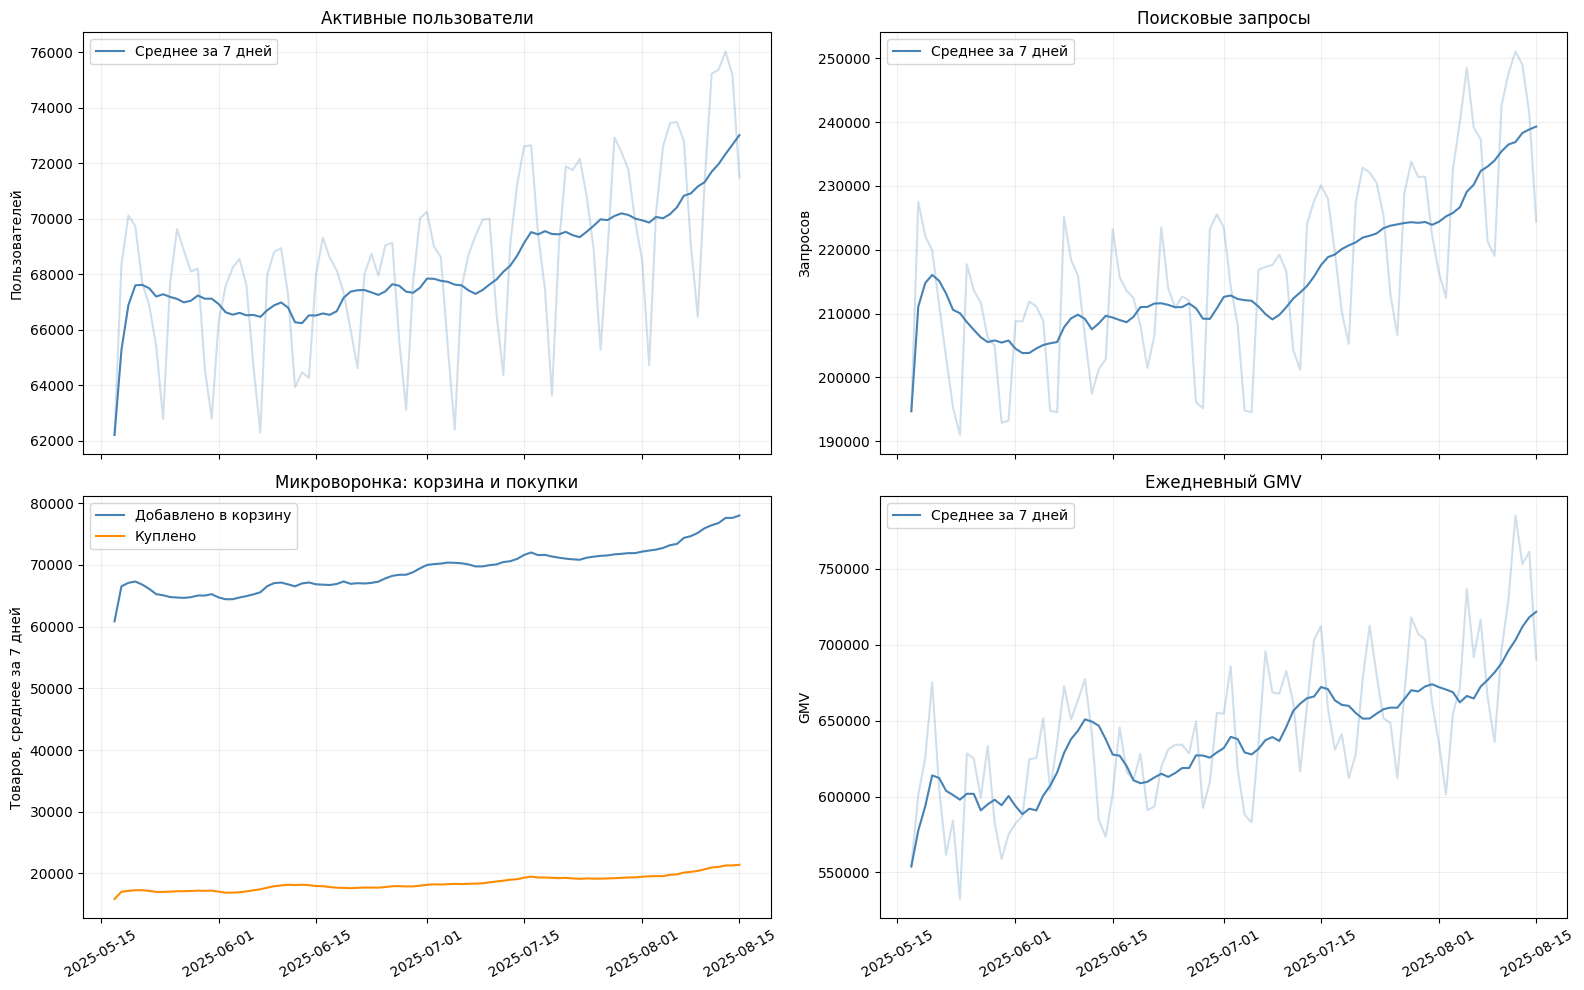

In [22]:
daily_metrics = (
    df.groupby("event_date", as_index=False)
    .agg(
        active_users=("user_id", "nunique"),
        searches=("searches", "sum"),
        cart_items=("to_cart", "sum"),
        purchased_items=("to_ord", "sum"),
        gmv=("gmv", "sum"),
    )
)

daily_metrics["event_date"] = pd.to_datetime(
    daily_metrics["event_date"]
)

rolling_columns = [
    "active_users",
    "searches",
    "cart_items",
    "purchased_items",
    "gmv",
]

for column in rolling_columns:
    daily_metrics[f"{column}_ma7"] = (
        daily_metrics[column]
        .rolling(window=7, min_periods=1)
        .mean()
    )

print(f"""
Дней в ежедневной таблице: {len(daily_metrics)}
Минимальная дата: {daily_metrics["event_date"].min().date()}
Максимальная дата: {daily_metrics["event_date"].max().date()}
""")

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 10),
    sharex=True,
)

axes[0, 0].plot(
    daily_metrics["event_date"],
    daily_metrics["active_users"],
    alpha=0.25,
    color="steelblue",
)

axes[0, 0].plot(
    daily_metrics["event_date"],
    daily_metrics["active_users_ma7"],
    color="steelblue",
    label="Среднее за 7 дней",
)

axes[0, 0].set_title("Активные пользователи")
axes[0, 0].set_ylabel("Пользователей")
axes[0, 0].legend()

axes[0, 1].plot(
    daily_metrics["event_date"],
    daily_metrics["searches"],
    alpha=0.25,
    color="steelblue",
)

axes[0, 1].plot(
    daily_metrics["event_date"],
    daily_metrics["searches_ma7"],
    color="steelblue",
    label="Среднее за 7 дней",
)

axes[0, 1].set_title("Поисковые запросы")
axes[0, 1].set_ylabel("Запросов")
axes[0, 1].legend()

axes[1, 0].plot(
    daily_metrics["event_date"],
    daily_metrics["cart_items_ma7"],
    color="steelblue",
    label="Добавлено в корзину",
)

axes[1, 0].plot(
    daily_metrics["event_date"],
    daily_metrics["purchased_items_ma7"],
    color="darkorange",
    label="Куплено",
)

axes[1, 0].set_title("Микроворонка: корзина и покупки")
axes[1, 0].set_ylabel("Товаров, среднее за 7 дней")
axes[1, 0].legend()

axes[1, 1].plot(
    daily_metrics["event_date"],
    daily_metrics["gmv"],
    alpha=0.25,
    color="steelblue",
)

axes[1, 1].plot(
    daily_metrics["event_date"],
    daily_metrics["gmv_ma7"],
    color="steelblue",
    label="Среднее за 7 дней",
)

axes[1, 1].set_title("Ежедневный GMV")
axes[1, 1].set_ylabel("GMV")
axes[1, 1].legend()

for axis in axes.flat:
    axis.grid(alpha=0.2)
    axis.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


Пиковый день по поиску:
Воскресенье

Пиковый день по покупкам:
Вторник

Пиковый день по GMV:
Вторник

Минимальный день по GMV:
Суббота



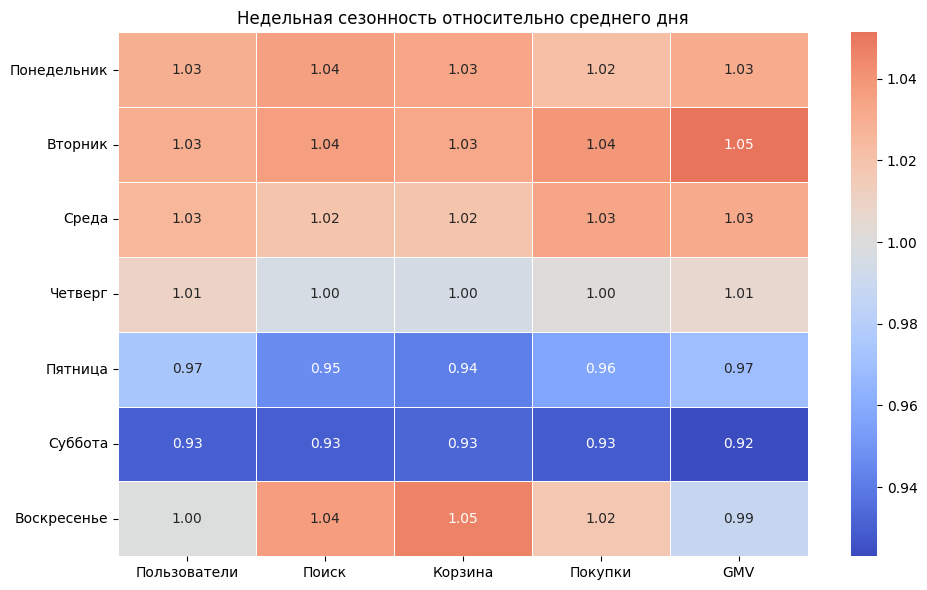

In [23]:
weekday_names = {
    0: "Понедельник",
    1: "Вторник",
    2: "Среда",
    3: "Четверг",
    4: "Пятница",
    5: "Суббота",
    6: "Воскресенье",
}

seasonality_columns = [
    "active_users",
    "searches",
    "cart_items",
    "purchased_items",
    "gmv",
]

weekday_metrics = (
    daily_metrics
    .assign(
        weekday=daily_metrics["event_date"].dt.dayofweek
    )
    .groupby("weekday")[seasonality_columns]
    .mean()
)

weekday_index = (
    weekday_metrics
    / daily_metrics[seasonality_columns].mean()
)

weekday_index = weekday_index.rename(
    index=weekday_names,
    columns={
        "active_users": "Пользователи",
        "searches": "Поиск",
        "cart_items": "Корзина",
        "purchased_items": "Покупки",
        "gmv": "GMV",
    },
)

# Seaborn не работает с object/Arrow dtype:
# преобразуем маленькую таблицу 7 × 5 в обычный float64.
weekday_index = pd.DataFrame(
    weekday_index.to_numpy(dtype="float64"),
    index=weekday_index.index,
    columns=weekday_index.columns,
)

print(f"""
Пиковый день по поиску:
{weekday_index["Поиск"].idxmax()}

Пиковый день по покупкам:
{weekday_index["Покупки"].idxmax()}

Пиковый день по GMV:
{weekday_index["GMV"].idxmax()}

Минимальный день по GMV:
{weekday_index["GMV"].idxmin()}
""")

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    weekday_index,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=1,
    linewidths=0.5,
    ax=ax,
)

ax.set_title("Недельная сезонность относительно среднего дня")
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

Индекс интерпретируется так:
- 1.00 - средний уровень;
- 1.10 - на 10% выше среднего;
- 0.90 - на 10% ниже среднего.

## Основные выводы

### Качество данных

За период с 17 мая по 15 августа 2025 года получено 6 235 139 дневных наблюдений по 227 663 пользователям, присутствующим в этом окне.

- пропуски отсутствуют;
- дубликаты `user_id × event_date` отсутствуют;
- отрицательные значения и некорректные бинарные флаги отсутствуют;
- показатели поиска и каталога полностью складываются в общие показатели.

### Распределение GMV

- 67 923 пользователя, или 29.83%, не принесли GMV;
- медианный GMV за 91 день — 60.84;
- 95-й процентиль — 1 109.80;
- 99-й процентиль — 2 659.30;
- 99.9-й процентиль — 7 118.72;
- skewness равен 13.00;
- excess kurtosis равен 422.62;
- коэффициент Джини равен 0.761;
- top-5% пользователей формируют 42.93% GMV;
- top-1% формируют 17.72% GMV;
- top-0.1% формируют 4.32% GMV.

Распределение имеет выраженную нулевую массу и тяжёлый правый хвост. `log1p` делает распределение положительного GMV заметно компактнее.

### RFM и поведение

Медианный пользователь:

- активен 23 дня из 91;
- совершает покупки в 2 различных дня;
- последний раз проявлял любую активность 2 дня назад;
- использовал поиск 3 дня назад;
- совершал покупку 12 дней назад;
- использовал каталог 16 дней назад.

Медианный GMV на один купленный товар равен 23.87. Медианный CV дневного GMV равен 5.90, поэтому покупки происходят всплесками. GMV на товар — не средний чек заказа.

### Поиск и каталог

Поиск является основным коммерческим каналом:

- через поиск проходит 94.55% купленных товаров;
- поиск формирует 92.69% GMV;
- SCI составляет 8.12 купленного товара на 100 поисковых запросов;
- конверсия поискового дня в покупку — 18.77%;
- конверсия каталожного дня — 7.32%.

Общий GMV полностью атрибутируется поиску и каталогу. Отдельный вклад рекомендаций или других каналов по доступным полям не обнаружен.

### Корзина

- 26.68% добавленных товаров впоследствии покупаются;
- в 57.34% дней с добавлением в корзину покупка в тот же день отсутствует.

Это прокси брошенной корзины: данные не позволяют связать конкретное добавление с конкретной последующей покупкой.

### Динамика и стабильность

Совокупная интенсивность последних семи дней выше среднедневного уровня за 91 день:

- поиск — в 1.10 раза;
- добавления в корзину — в 1.12 раза;
- покупки — в 1.15 раза.

При сравнении двух равных 45-дневных периодов также наблюдается рост:

- поисковые запросы — на 7.25%;
- добавления в корзину — на 9.13%;
- купленные товары — на 11.70%.

Рост или появление активности корзины наблюдается у 41.89% пользователей, снижение или прекращение — у 34.79%.

Медианный CV ежедневной вовлечённости равен 2.80, что указывает на нерегулярное и всплесковое поведение пользователей.

### Недельная сезонность

Воскресенье лидирует по поиску (+3.71% к среднему) и добавлениям в корзину (+4.63%). Вторник лидирует по покупкам (+3.89%) и GMV (+5.13%). Минимальный GMV наблюдается в субботу — на 7.69% ниже среднего.

### Репрезентативность окна

Окно содержит ровно 13 недель и не включает предновогодний спрос и новогодний провал. Поэтому оценки недельной сезонности и краткосрочной динамики меньше искажены календарными праздниками. Однако один 91-дневный срез не описывает весь год и не заменяет сравнение нескольких сезонных окон.

### Ограничения

- анализ относится только к 227 663 пользователям, наблюдаемым в выбранном окне, и не содержит будущего target;
- `to_ord` отражает число купленных товаров, а не заказов;
- `searches` отражает число запросов, а не поисковых сессий;
- показатели корзины не отслеживают путь одного товара между днями;
- обнаруженные связи и изменения не доказывают причинность или отток.

In [24]:
source_gmv = float(df["gmv"].sum())
user_gmv_check = float(user_rfm["gmv_91d"].sum())
daily_gmv_check = float(daily_metrics["gmv"].sum())

channel_gmv_error = np.abs(
    user_rfm["gmv_91d"].to_numpy(dtype="float64")
    - user_rfm["gmv_search_91d"].to_numpy(dtype="float64")
    - user_rfm["gmv_cat_91d"].to_numpy(dtype="float64")
)

assert df["event_date"].min() == period_start
assert df["event_date"].max() == period_end
assert df["event_date"].nunique() == 91
assert len(user_rfm) == df["user_id"].nunique()
assert user_rfm["user_id"].is_unique
assert len(daily_metrics) == 91
assert daily_metrics["event_date"].is_unique
assert np.isclose(source_gmv, user_gmv_check, atol=1e-6)
assert np.isclose(source_gmv, daily_gmv_check, atol=1e-6)
assert channel_gmv_error.max() < 1e-8
assert np.isclose(gini_lorenz, gini_ranks)
assert trend_summary["Пользователей"].sum() == len(user_rfm)

print(f"""
ФИНАЛЬНАЯ ПРОВЕРКА

Период: {period_start} — {period_end}
Строк: {len(df):,}
Дней: {df["event_date"].nunique()}
Пользователей: {df["user_id"].nunique():,}

GMV в исходных данных: {source_gmv:,.2f}
GMV в user_rfm: {user_gmv_check:,.2f}
GMV в daily_metrics: {daily_gmv_check:,.2f}

Максимальная ошибка канальной атрибуции: {channel_gmv_error.max():.12f}
Gini по двум формулам: {gini_lorenz:.6f} и {gini_ranks:.6f}

Все проверки пройдены.
""")


ФИНАЛЬНАЯ ПРОВЕРКА

Период: 2025-05-17 — 2025-08-15
Строк: 6,235,139
Дней: 91
Пользователей: 227,663

GMV в исходных данных: 58,523,035.46
GMV в user_rfm: 58,523,035.46
GMV в daily_metrics: 58,523,035.46

Максимальная ошибка канальной атрибуции: 0.000000000017
Gini по двум формулам: 0.760771 и 0.760771

Все проверки пройдены.

